In [1]:
%load_ext autoreload
%autoreload 3

## Arquitetura

### Arquitetura geral

```mermaid
graph TD
    %% Definição dos nós
    Start(( )) --> A[1. Boas-vindas]
    
    A -->|Usuário requisita informações| B[2. Retorna informações]
    
    B --> C{Usuário realiza<br/>nova pergunta?}
    
    %% Transições da decisão
    C -->|Nova requisição| B
    C -->|Responde pergunta| D[Responde]
```
---

1. **Boas vindas:** Chatbot inicia a conversa explicando brevemente qual é o seu proposito, talvez com algumas perguntas de exemplo.
2. **Retorna informações:** Nessa etapa é devolvido as informações requisitadas pelo usuário com base nos recursos disponíveis no banco de dados do governo federal.
3. **Usuário realiza nova pergunta:** Usuário faz uma nova pergunta, o agente decidirá se é necessário fazer uma nova pesquisa no banco de dados ou se já possui o necessário para responde-la.
4. **Responde:** O chatbot responde ao usuário com base nos dados já adquiridos, explicando-os com mais detalhes ou gerando gráficos para uma melhor interpretação dos dados(ainda em desenvolvimento)

## Estrutura interna

### LLM

**Escolha do modelo**

No momento não foi determinado o modelo ideal, mais testes e pesquisas precisam ser feitos. Entretanto o chatbot está sendo construido de forma que possa ser alimentado por qualquer modelo, de forma que o chatbot possa ser atualizado com novos modelos com pouca ou nenhum alteração do código original ou parametros de calibração.

Para selecionar o modelo adequado foram estão sendo analizados os seguintes critérios:
* Janela de contexto
* Quantidade de parametros
* Capacidade de thinking nativo
* Capacidade de interpretar imagens
* Tempo médio de resposta
* Infraestrutura exigida

Segundo o artigo https://arxiv.org/pdf/2405.03146v2 é possível obter resultados melhores com modelos quantizados(como 4b) com um maior numero de parametros do que sua contraparte com menor numero de parametros mas com precisão maior(como b16)

**Pre-requisitos**
* Modelos maiores ou iguais a 4B de parametros. Os teste de geração de código mostraram que LLMs menores que 4B de parametros não foram capazes de seguirem as ordens e gerar códigos eficientes.


### Inference engine

No começo utilizamos a biblioteca transformers, entretanto com novas pesquisas a biblioteca llama-cpp parece ser mais adequada para o desenvolvimento do chatbot por possuir a seguintes caracteristicas:

* Menor consumo de Vram
* Flexibilidade, pode ser usada tanto em linux quanto em windows
* Maior facilidade de usar modelos quantizados
* Maior controle na saída da LLM, o llama-cpp permite estruturar a saída como parametro de entrada da engine, diferente do transformers que só pode ser definido através do system prompt
* Suporte a tools

### Instanciando modelo

Vamos utilizar de exemplo o modelo "Qwen3-4B-Instruct-2507-UD-Q4_K_XL", este é um modelo de 4B de parametros quantizado em 4bits usando GGUF.


In [2]:
from chatbot.llm import LLML
from config.paths import MODELOS

llm_wrapper=LLML(model_path=str(MODELOS['Qwen3-4B-Instruct-2507-UD-Q4_K_XL']),
                                n_gpu_layers=-1, verbose=False, n_ctx=2**14,)

/home/migueldcarvalho/miniforge3/envs/geral/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/migueldcarvalho/miniforge3/envs/geral/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
llama_context: n_ctx_per_seq (16384) < n_ctx_train (262144) -- the full capacity of the model will not be utilized


A classe LLML é uma classe criada para facilitar o processo de inference, ela herda diretamente da classe 

### Agente

Criar uma lógica de agentes manualmente apesar de trazer um grande controle sobre a aplicação, é demorado e dependendo da complexidade do chatbot pode ser complexo.
Langgraph é um framework de criação de agente que permite faciliade e agilidade no desenvolvimento sem perder controle da aplicação

Grafo gerado pelo langgrapg

/home/migueldcarvalho/miniforge3/envs/geral/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/migueldcarvalho/miniforge3/envs/geral/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


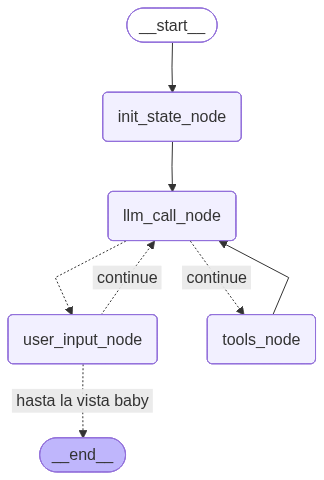

In [2]:
from chatbot.graph import chat_graph

graph = chat_graph()
graph

### Tools

O chatbot consiste em um agente que possui, até o momento, as seguintes tools:

1. Busca por recursos especificos
2. Analise de dados

Caso o usuário requisite o agente pode retorna apenas os recurso associados a sua pergunta.

Caso a pergunta seja mais genérica como "Qual estado possui a maior quantidade de multas ambientais?", o agente agirá de forma mais autonoma, selecionando os recursos por conta própria por meio de semantic search e analizando-os por meio de tecnicas de **RAG**, como **Semantic search** ou **Tabular question answering** (**TQA**)

#### Analise de dados

Nessa etapa o algoritmo identifica classifica o tipo de dado como tabular (CSV, XML...) ou textual (PDF), e utiliza um sistema de RAG para busca informações relevantes dentro dos dados.

A escolha da VectorStore foi Qdrant por ser fácil de usar, possui boa documentação e bários recursos interessantes como pesquisa hibrida, filtros, quantização de modelos embedding.

In [4]:
from qdrant_client import QdrantClient
from config.paths import VECTOR_STORE
from sentence_transformers import SentenceTransformer

model_name = "Qwen/Qwen3-Embedding-0.6B"

encoder = SentenceTransformer(model_name, device='cuda')#, model_kwargs={"local_files_only": True})
client = QdrantClient(path=VECTOR_STORE) # Carrega vectorstore

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 15850.14it/s]
/tmp/ipykernel_8344/1755650932.py:8: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Collection <Recurso_metadados> contains 63190 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client = QdrantClient(path=VECTOR_STORE) # Carrega vectorstore


In [5]:
import uuid

state = {}

config = {'configurable': {
            'thread_id': uuid.uuid4(),
            'llm': 'llm_model', 
            'tokenizer': 'tokenizer',
            'llm_wrapper': llm_wrapper,
            'encoder': encoder,
            'client': client
            }}

##### **Dados textuais**

um documento textual é fragmentado em chunks, e por meio de um modelo de embedding, serão transformados em tensores, que guardam as relações semânticas, e armazenados em uma vectorstore para serem comparados a partir de metricas com a pergunta do usuário, também em forma de tensor, para descobrir qual chunk é o mais provavel de possuir o conteudo que o usuário deseja. Dessa forma o chunk é enviado a LLM que analisa e responde de acordo no contexto adequado.

In [27]:
from chatbot.tools.utils import download_resource

link_pdf = {
    'dicionario': "https://www.ans.gov.br/images/stories/Materiais_para_pesquisa/Perfil_setor/dados_abertos/dicionario_dados_abertos_ANS_Dados_Gerais_das_reclamacoes_por_operadora.pdf",
    'municipio': "https://dados.al.gov.br/catalogo/dataset/d2246f56-cb12-4318-836c-d6ca4cc8d4ae/resource/6cf64862-6b4b-4729-99a4-ebf4d8afaf90/download/municipalinhapi2013.pdf"}
linkp = link_pdf['municipio']
download_resource(linkp)

"Erro ao conectar com servidor: HTTPSConnectionPool(host='dados.al.gov.br', port=443): Read timed out. (read timeout=10)"

In [28]:
from chatbot.tools.pdf_reader import text_query
from chatbot.utils import debug

queries1 = ["Qual é a extensão da rede saneamento de esgoto?"] 

query = queries1[0]

response = text_query(config=config, query=query, source={'link': linkp})
debug()(response)


ic| pdf_reader.py:14 in embed_texts()- f"Tamanho do texto: {len(texts)}": 'Tamanho do texto: 37'

ic| pdf_reader.py:16 in embed_texts()- i: 0

ic| pdf_reader.py:16 in embed_texts()- i: 5

ic| pdf_reader.py:16 in embed_texts()- i: 10

ic| pdf_reader.py:16 in embed_texts()- i: 15

ic| pdf_reader.py:16 in embed_texts()- i: 20

ic| pdf_reader.py:16 in embed_texts()- i: 25

ic| pdf_reader.py:16 in embed_texts()- i: 30

ic| pdf_reader.py:16 in embed_texts()- i: 35

ic| pdf_reader.py:93 in text_query()
     hit.payload['page_content']: '''Perfil Municipal Inhapi
                                   V - INFRAESTRUTURA
                                   5.1 Saneamento: Serviços de Água e Esgoto
                                   Especificação
                                   Água Esgoto
                                   2010
                                   Extensão da Rede (Km) 11,49 0,00
                                   População Total Atendida  com Rede (habitantes) - 0
               

['Perfil Municipal Inhapi\nV - INFRAESTRUTURA\n5.1 Saneamento: Serviços de Água e Esgoto\nEspecificação\nÁgua Esgoto\n2010\nExtensão da Rede (Km) 11,49 0,00\nPopulação Total Atendida  com Rede (habitantes) - 0\nPopulação total atendida com abastecimento (habitantes) 6.556 -\nQuantidade de Economias Ativas (Número) 1.860 0\nQuantidade de Ligações Ativas (Número) 2.236 0\nVolume Coletado (1000 m³) - 0,00\nVolume Consumido (1000 m³) 176,00 -\nVolume Faturado (1000 m³) 238,59 0,00\nVolume Produzido (1000 m³) 370,00 -\nVolume Tratado (1000 m³) - 0,00\nFonte: Sistema Nacional de Informações sobre Saneamento - SNIS\n5.2 Energia Elétrica: Consumo e Consumidores por Classe\nClasses\nConsumo (Mwh) Consumidores\n2011\nComercial 130287\nIluminação Pública 1534\nIndustrial 925\nPoder Público 59132\nPróprio 11\nResidencial 4.7152.953\nRural 3576\nServiço Público 11\nTotal 4.9514.009\nFonte: Eletrobrás - Distribuidora Alagoas\n - 10 -',
 'Perfil Municipal Inhapi\nV - INFRAESTRUTURA\n5.1 Saneamento: S

##### **Dados tabulares**

O modelo atua como um tradutor de perguntas em linguagem natural para SQL queries de forma que possam ser extraidos dados relevantes da tabela. Após esses dados serem extraidos são armazenados no estado doa agente para serem usados quando necessário.

Antes da query ser enviada para o agente de geração de SQL, é feita uma pre-análise da tabela, recolhendo metados como colunas, numero de colunas, tipos de cada coluna e algumas métricas como desvião padrão, dessa forma o agente consegue gerar um código melhor.

Obs: Vários catalogos apresentaram um documento pdf explicando detalhadamente os metadados de alguns ou todos recursos presentes no catalogo, ainda não foi implementado, mas esse arquivo pode ser restreado para ajudar na compreensão do agente a fim de gerar códigos melhores, já que algumas colunas não possuem nomes autoexplicativos.

In [29]:
from chatbot.tools.utils import download_resource

link_csv = {'gas': "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/anuario-estatistico-2022/tabelas/anuario-2022-dados_abertos-tabela2-60.csv"}

linkc = link_csv['gas']
download_resource(linkc)

200

In [23]:
from chatbot.tools.tools import tabular_query
from chatbot.utils import debug

queries0 = ["Para qual pais o Brasil mais exporta gás natural?",        
            "Para qual pais o Brasil mais exportou gás natural em 2017?",
            "Qual é o total de importações de gás natural por páis",
            "Para quais paises o brasil exportou gas natural liquefeito?",
            "Quais paises tiveram importações acima de 10 mil em 2015",
            ] 

query = queries0[0]

response = tabular_query(state=state, config=config, query=query, source={'link': linkc})


display(response['dataframe'])
print(response['code'])


ic| tools.py:109 in tabular_query()- f"teste {link}": 'teste https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/anuario-estatistico-2022/tabelas/anuario-2022-dados_abertos-tabela2-60.csv'

ic| tabular_reader.py:111 in tabular_analysis()- 'DataFrame carregado'

ic| tabular_reader.py:115 in tabular_analysis()- 'pre-análise concluida...'

ic| tabular_reader.py:100 in generate_query()
     system_prompt: '''### IDENTITY
                       You are an expert Data Engineer and Data Analyst, specializing in writing advanced SQLite queries to answer analytical questions.
                     
                     ### OBJECTIVE
                       Generate valid, highly efficient SQLite code to answer the user's question based strictly on the provided CSV metadata.
                     
                     ### STRICT RULES
                       1. ONLY output valid SQL code enclosed within <code> </code> tags.
                       2. Absolutely NO markdown forma

,PAÍS
0,Bolívia


<code>
SELECT "PAÍS" 
FROM dt_table 
WHERE "TIPO DE PRODUTO" = 'Gás Natural (a)' 
ORDER BY "IMPORTAÇÃO DE GÁS NATURAL" DESC 
LIMIT 1
</code>


In [12]:
from pandasql import sqldf
import pandas as pd
from chatbot.tools.utils import GovPath
from chatbot.tools.tabular_reader import encoding_type

link = linkc

paths = GovPath(link)

sql_query ='''
SELECT "PAÍS", "IMPORTAÇÃO DE GÁS NATURAL"
FROM dt_table
WHERE "ANO" = 2015 AND "IMPORTAÇÃO DE GÁS NATURAL" > 10000
'''

dt_table = pd.read_csv(paths.datapath, encoding=encoding_type(paths.datapath), on_bad_lines='skip', sep=';', decimal=',')
res = sqldf(sql_query, {'dt_table': dt_table})
res

,PAÍS,IMPORTAÇÃO DE GÁS NATURAL
0,Bolívia,11684.19142


#### **Dados gerais**

In [31]:
from chatbot.tools.tools import answering_question
from chatbot.utils import debug

query = ["Qual estado possui a maior quantidade de multas ambientais?",
         "Quais paises mais importam petróleo do Brasil?"]

response = answering_question(state=state, config=config, query=query[1])
debug()(response)


ic| tools.py:37 in answering_question()- f"teste {link}": 'teste https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/anuario-estatistico-2023/secao-2/csv/tabela2-51.csv'

ic| tools.py:47 in answering_question()- format: 'csv'

ic| tabular_reader.py:111 in tabular_analysis()- 'DataFrame carregado'

ic| tabular_reader.py:115 in tabular_analysis()- 'pre-análise concluida...'

ic| tabular_reader.py:100 in generate_query()
     system_prompt: '''### IDENTITY
                       You are an expert Data Engineer and Data Analyst, specializing in writing advanced SQLite queries to answer analytical questions.
                     
                     ### OBJECTIVE
                       Generate valid, highly efficient SQLite code to answer the user's question based strictly on the provided CSV metadata.
                     
                     ### STRICT RULES
                       1. ONLY output valid SQL code enclosed within <code> </code> tags.
                 

{'tabular_data': ToolMessage(content='a', tool_call_id='b33bf47b-c6c3-47f4-ae3a-14718f9410a8'),
 'text_data': ToolMessage(content='a', tool_call_id='062929ad-d783-4883-92fd-93df2da44398')}

In [32]:
response['tabular_data'].additional_kwargs['dataframe']

,PAÍS


In [37]:
print(response['tabular_data'].additional_kwargs)
print(response['text_data'].additional_kwargs)

{'origin': 'https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/anuario-estatistico-2023/secao-2/csv/tabela2-51.csv', 'dataframe': Empty DataFrame
Columns: [PAÍS]
Index: []}
{'origin': 'https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/anuario-estatistico-2023/secao-2/metadados/tabela2-54.pdf', 'chunk': ['TÍTULO: Tabela 2.54 – Importação de derivados de petróleo, segundo Regiões Geográficas, Países e Blocos \nEconômicos de procedência \n \nSEÇÃO 1: COLUNAS \n \nNOME DA COLUNA DESCRIÇÃO TIPO DO DADO \nREGIÃO GEOGRÁFICA \nRegião Geográfica – América do Norte, Américas Central e \ndo Sul, Europa, Comunidade dos Estados Independentes, \nOriente Médio, África e Ásia-Pacífico. \nTexto \nPAÍS   País de origem Texto \nPRODUTO   \nTipo de produto combustível: Nafta \nÓleo diesel \nGasolina A \nQAV \nCoque \nGLP¹ \nLubrificante \nSolvente \nOutros \nTexto \nIMPORTAÇÃO DE DERIVADOS DE \nPETRÓLEO \nVolume importado de derivados em mil metros cúbicos \n(m

## Chatbot

### Funcionamento

#### funções auxiliares

In [29]:
from langchain_core.messages import BaseMessage   # Classe pai que dá origem a todos os tipos de messagem no langchain
from langchain_core.messages import ToolMessage   # Classe que gerencia messagens/respotas das tools
from langchain_core.messages import HumanMessage
from langchain_core.messages import AIMessage
from langchain_core.messages import SystemMessage 

from icecream import ic

import pandas as pd

def role(message: BaseMessage)-> str:
    if isinstance(message, HumanMessage):
        return "user"
    else:
        return "assistant"

def show_messages(messages: list)-> None:
    
    for message in messages:
        if isinstance(message, AIMessage):
            ic(message.content)
        elif isinstance(message, ToolMessage):
            ic(message.content)
            if isinstance(message.additional_kwargs, dict):
                display(message.additional_kwargs)
                display(pd.DataFrame.from_dict(message.additional_kwargs.get('dataframe')))
        elif isinstance(message, HumanMessage):
            ic(message.content)
        elif isinstance(message, SystemMessage):
            ic(message.content)
        else:
            ic(f"Não é uma BaseMessage: {type(message)} {message}")

#### Testes pre-definidos

In [30]:
from langgraph.types import Command
from chatbot.graph import chat_graph
import uuid

def llama_config():
    return {'configurable': {
            'thread_id': uuid.uuid4(),
            'llm': 'llm_model', 
            'tokenizer': 'tokenizer',
            'llm_wrapper': llm_wrapper,
            'encoder': encoder,
            'client': client
            }}

config = llama_config()

queries = [
        ["Qual estado possui a maior quantidade de multas ambientais?",
         "Quais são os 5 estados quem possuem a maior quantidade de multas ambientais?"],

        ["Qual é o preço de tarifas de exportação e produtos eletronicos?",
        "Quantos pessoas nasceram em 2024?"]]

prompts = ["Olá", queries[0][1]]

def testes():
    messages = []

    graph = chat_graph()
    print(prompts[0])
    for chunk in graph.stream({'messages': [prompts[0]]}, config, stream_mode='messages'):
        messages.append(chunk[0])
    
    for prompt in prompts[1:]:
        print(prompt)
        command = Command(resume=prompt)
        for chunk in graph.stream(command, config, stream_mode='messages'):
            messages.append(chunk[0])
    
    return messages, graph.get_state(config)
        
messages, graph_state = testes()
show_messages(messages)

Olá

ic| graph.py:45 in init_state()- 'Inicializando...'

ic| graph.py:53 in llm_call()- response: AIMessage(content='Olá! Como posso ajudar você hoje? 😊', additional_kwargs={'thinking': None}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])
Quais são os 5 estados quem possuem a maior quantidade de multas ambientais?

ic| graph.py:53 in llm_call()
     response: AIMessage(content='<tool_call>
               {"name": "answering_question", "arguments": {"query": "5 estados com maior quantidade de multas ambientais"}}
               </tool_call>', additional_kwargs={'thinking': None}, response_metadata={}, tool_calls=[{'name': 'answering_question', 'args': {'query': '5 estados com maior quantidade de multas ambientais'}, 'id': 'call_034fd2a9', 'type': 'tool_call'}], invalid_tool_calls=[])

ic| tools.py:37 in answering_question()- f"teste {link}": 'teste https://dadosabertos.ibama.gov.br/dados/SICAFI/AC/Quantidade/multasDistribuidasBensTutelados.html'

ic| tools.py:47 in answer

{}

""



ic| 407758180.py:21 in show_messages()- message.content: 'Olá! Como posso ajudar você hoje? 😊'

ic| 407758180.py:28 in show_messages()- message.content: 'Quais são os 5 estados quem possuem a maior quantidade de multas ambientais?'

ic| 407758180.py:21 in show_messages()
     message.content: '''<tool_call>
                       {"name": "answering_question", "arguments": {"query": "5 estados com maior quantidade de multas ambientais"}}
                       </tool_call>'''

ic| 407758180.py:23 in show_messages()- message.content: 'a'


{'origin': 'https://www.tesourotransparente.gov.br/ckan/dataset/f04a675e-4e5a-4e88-98de-acc3e22bf778/resource/58a9df19-5b0f-4bac-af00-254ff2a969ff/download/Capag-Estados-2022-1-revisada.csv',
 'dataframe': {'UF': ['AC', 'AL', 'AM', 'AP', 'BA'],
  'Unnamed: 9': [None, None, None, None, None]}}

,UF,Unnamed: 9
0,AC,None
1,AL,None
2,AM,None
3,AP,None
4,BA,None



ic| 407758180.py:21 in show_messages()- message.content: 'Atualmente, não há dados disponíveis no banco de dados brasileiro que mostrem os 5 estados com a maior quantidade de multas ambientais. Para obter essa informação, seria necessário acesso a um sistema específico de monitoramento ambiental ou a dados oficiais de órgãos como a Secretaria de Meio Ambiente ou a Agência Nacional de Energia Elétrica (ANEEL). Se quiser, posso ajudar a buscar outras informações sobre meio ambiente ou políticas públicas. 😊'


In [31]:
show_messages(messages)


ic| 407758180.py:23 in show_messages()- message.content: ''


{}

""



ic| 407758180.py:21 in show_messages()- message.content: 'Olá! Como posso ajudar você hoje? 😊'

ic| 407758180.py:28 in show_messages()- message.content: 'Quais são os 5 estados quem possuem a maior quantidade de multas ambientais?'

ic| 407758180.py:21 in show_messages()
     message.content: '''<tool_call>
                       {"name": "answering_question", "arguments": {"query": "5 estados com maior quantidade de multas ambientais"}}
                       </tool_call>'''

ic| 407758180.py:23 in show_messages()- message.content: 'a'


{'origin': 'https://www.tesourotransparente.gov.br/ckan/dataset/f04a675e-4e5a-4e88-98de-acc3e22bf778/resource/58a9df19-5b0f-4bac-af00-254ff2a969ff/download/Capag-Estados-2022-1-revisada.csv',
 'dataframe': {'UF': ['AC', 'AL', 'AM', 'AP', 'BA'],
  'Unnamed: 9': [None, None, None, None, None]}}

,UF,Unnamed: 9
0,AC,None
1,AL,None
2,AM,None
3,AP,None
4,BA,None



ic| 407758180.py:21 in show_messages()- message.content: 'Atualmente, não há dados disponíveis no banco de dados brasileiro que mostrem os 5 estados com a maior quantidade de multas ambientais. Para obter essa informação, seria necessário acesso a um sistema específico de monitoramento ambiental ou a dados oficiais de órgãos como a Secretaria de Meio Ambiente ou a Agência Nacional de Energia Elétrica (ANEEL). Se quiser, posso ajudar a buscar outras informações sobre meio ambiente ou políticas públicas. 😊'


#### Teste interativo

In [ ]:
def llama_config():
    return {'configurable': {
            'thread_id': uuid.uuid4(),
            'llm': 'llm_model', 
            'tokenizer': 'tokenizer',
            'llm_wrapper': llm_wrapper,
            'encoder': encoder,
            'client': client
            }}

def interativo():
    graph = chat_graph()

    prompt = "Olá"
    while prompt != 'quit':
        for chunk in graph.stream({'messages': [prompt]}, config, stream_mode='messages'):
            messages.append(chunk)
        show_messages(messages)
        prompt = input("User> ")

### problemas e limitações